# Análise Exploratória Univariada - SIA/SUS
Baseado no roteiro de auditoria estatística para variáveis quantitativas e qualitativas.

In [1]:
import os
import sys
import inspect

# Adicionar o diretório raiz do projeto ao path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from dotenv import load_dotenv
from src.analysis.data_quality import DataQualityAuditor
from src.analysis.univariate_auditor import UnivariateAuditor

# Carga de Dados
load_dotenv(dotenv_path="../.env")
db_auditor = DataQualityAuditor(os.getenv("DB_URL"))
df = db_auditor.fetch_data()

[DB] Arquivo local não encontrado. Consultando banco de dados (isso pode demorar)...
[CACHE] Salvando dados localmente em: data/processed\producao_ambulatorial_cache.parquet



ANALISANDO COLUNA: quantidade_aprovada

--- Estatísticas Descritivas ---
count    4.878560e+06
mean     1.247114e+03
std      3.621776e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.509504e+07
Name: quantidade_aprovada, dtype: float64
Coeficiente de Variação: 2904.13%
Erro Padrão da Média: 16.3974

--- Medidas de Forma ---
Assimetria (Skewness): 117.1371
Curtose (Kurtosis): 22743.3117

--- Teste de Normalidade (Shapiro-Wilk) ---
Estatística: 0.0277, p-valor: 3.4600e-95
Resultado: Não segue distribuição Normal

Outliers Detectados: 976696 (Limites: 0.00 a 0.00)


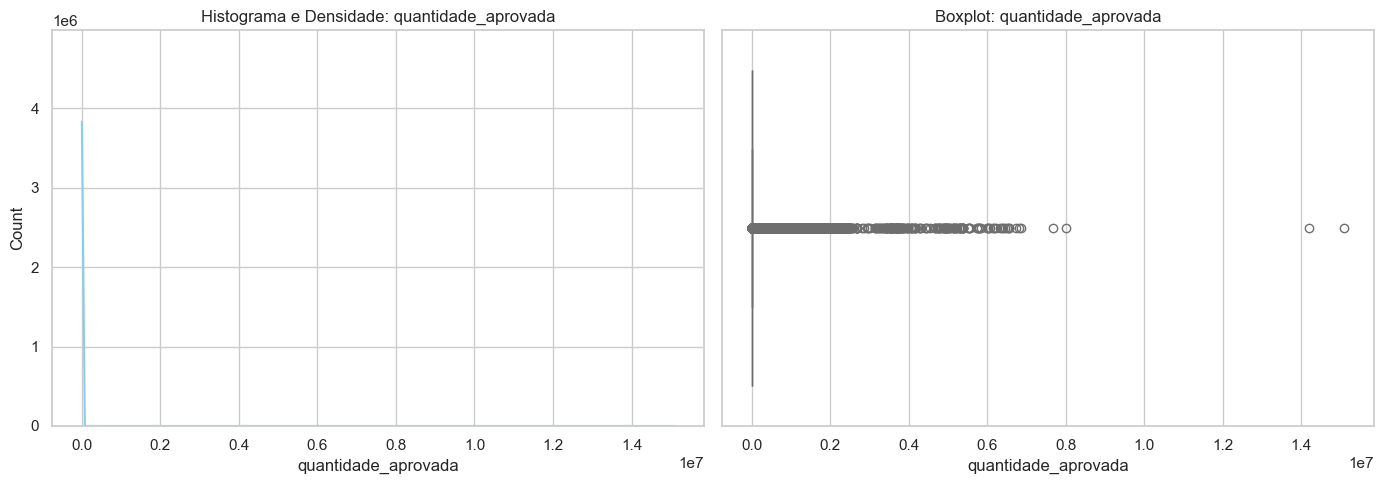


ANALISANDO COLUNA: valor_aprovado

--- Estatísticas Descritivas ---
count    4.878560e+06
mean     8.805659e+03
std      1.423866e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.245695e+07
Name: valor_aprovado, dtype: float64
Coeficiente de Variação: 1616.99%
Erro Padrão da Média: 64.4649

--- Medidas de Forma ---
Assimetria (Skewness): 57.0859
Curtose (Kurtosis): 5594.5908

--- Teste de Normalidade (Shapiro-Wilk) ---
Estatística: 0.0466, p-valor: 1.0015e-94
Resultado: Não segue distribuição Normal

Outliers Detectados: 781962 (Limites: 0.00 a 0.00)


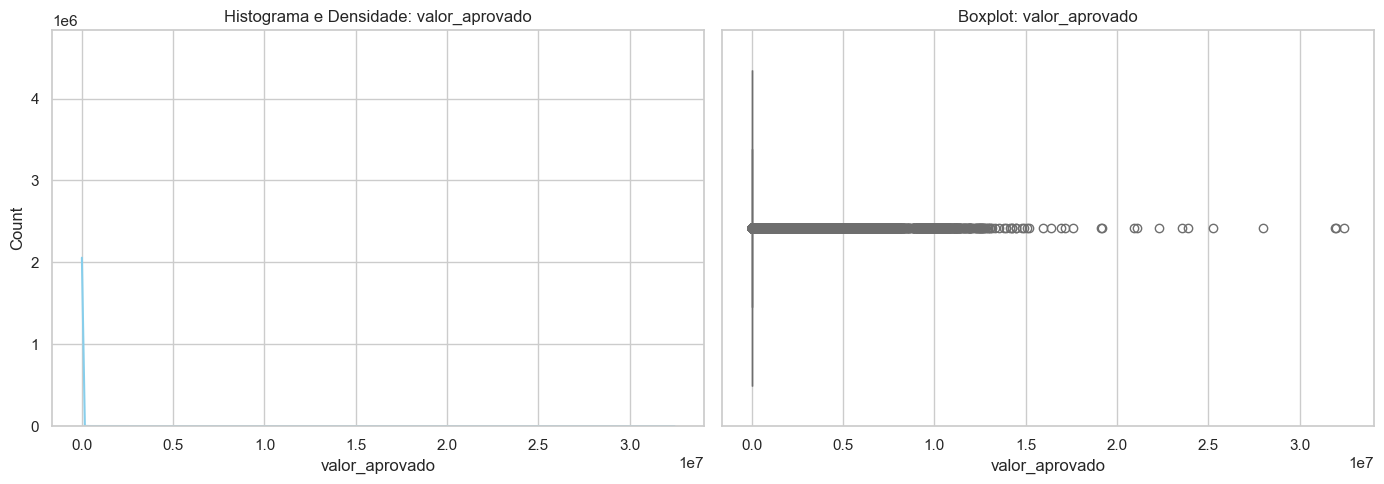

In [2]:
# Execução da Auditoria seguindo o fluxo pré-definido
auditor_uni = UnivariateAuditor(df)

# Pulando colunas de identificação
colunas_ruido = ['id', 'municipio_codigo', 'municipio_nome', 'subgrupo_procedimento', 'periodo']
auditor_uni.analisar_tudo(cols_to_exclude=colunas_ruido)